In [1]:
"""
Cityscapes UNetV4-Akida Decoder
Description:
    - Trains MobileNetV4 encoder + Akida-friendly decoder on Cityscapes.
    - Supports training on random crops of size 384*384 on half-resolution cityscape images, Hann-window inference, weighted CE loss.
Dependencies:
    albumentations, timm>=0.9.10, torchmetrics, matplotlib, opencv-python.
"""


'\nCityscapes UNetV4-Akida Decoder\nDescription:\n    - Trains MobileNetV4 encoder + Akida-friendly decoder on Cityscapes.\n    - Supports training on random crops of size 384*384 on half-resolution cityscape images, Hann-window inference, weighted CE loss.\nDependencies:\n    albumentations, timm>=0.9.10, torchmetrics, matplotlib, opencv-python.\n'

In [2]:

# !pip install -q segmentation-models-pytorch albumentations torchmetrics timm

import os, random, time, copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchmetrics import JaccardIndex
# import segmentation_models_pytorch as smp

# Optional: for mask/image tiling visualization
import cv2
import timm


In [3]:
import random
import numpy as np
import torch

#  Set random seed everywhere
SEED = 17
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [4]:
def to_one_hot(y, num_classes):
    return y if y.ndim == 2 else torch.nn.functional.one_hot(y, num_classes=num_classes).float()

class AsymmetricPaddedConv(nn.Module):
    def __init__(self, original_conv, pads_list):
        super().__init__()
        self.pads_list = pads_list
        self.conv = original_conv
        self.conv.padding = (0, 0)

    def forward(self, x):
        x = F.pad(x, self.pads_list, "constant", 0)
        return self.conv(x)
    
class SplittedDWConv(nn.Module):
    def __init__(self, original_conv):
        super().__init__()
        self.dw_k5_s1 = copy.deepcopy(original_conv)
        self.dw_k5_s1.stride = (1, 1)
        self.dw_k5_s1.padding = (2, 2)
        num_channels = original_conv.in_channels

        identity_conv = nn.Conv2d(
            in_channels=num_channels,
            out_channels=num_channels,
            kernel_size=3,
            stride=2,
            padding=0,
            groups=num_channels,
            bias=False
        )

        with torch.no_grad():
            identity_weights = torch.zeros_like(identity_conv.weight)
            identity_weights[:, 0, 1, 1] = 1
            identity_conv.weight.copy_(identity_weights)
            identity_conv.weight.requires_grad = False
            
        self.dw_k3_s2_identity = AsymmetricPaddedConv(
            identity_conv,
            pads_list=[0, 1, 0, 1]
        )

    def forward(self, x):
        x = self.dw_k5_s1(x)
        x = self.dw_k3_s2_identity(x)
        return x
    
def get_module_by_name(model, name):
    names = name.split('.')
    module = model
    for n in names:
        module = getattr(module, n)
    return module

def set_module_by_name(model, name, new_module):
    names = name.split('.')
    parent_module = model
    for i in range(len(names) - 1):
        parent_module = getattr(parent_module, names[i])
    setattr(parent_module, names[-1], new_module)


def patch_mobilenetv4_for_akida(model_to_patch):
    model = copy.deepcopy(model_to_patch)
    padding_map = {
        'conv_stem': [0, 1, 0, 1],
        'blocks.0.0.conv': [0, 1, 0, 1],
        'blocks.1.0.conv': [0, 1, 0, 1],
        'blocks.3.0.dw_mid.conv': [0, 1, 0, 1],
        'blocks.2.0.dw_mid.conv': [1, 2, 1, 2],
    }

    print("Starting model patching process")

    module_names = [name for name, _ in model.named_modules()]

    for name in module_names:
        try:
            module = get_module_by_name(model, name)
        except AttributeError:
            continue
        if isinstance(module, nn.Conv2d) and module.kernel_size == (5, 5) and module.stride == (2, 2) and module.groups == module.in_channels:
            print(f"  - Found unsupported DWConv. Replacing '{name}'...")
            unsupported_layer = get_module_by_name(model, name)
            new_layer = SplittedDWConv(unsupported_layer)
            set_module_by_name(model, name, new_layer)
            continue
        if name in padding_map:
            print(f"  - Found layer for padding fix. Replacing '{name}'...")
            original_layer = get_module_by_name(model, name)
            pads_list = padding_map[name]
            new_layer = AsymmetricPaddedConv(original_layer, pads_list)
            set_module_by_name(model, name, new_layer)

    print("Patching complete.")
    return model

# Example usage:
# original_model = timm.create_model(
#     "mobilenetv4_conv_small.e2400_r224_in1k",
#     pretrained=True,
#     num_classes= X #enter your number of classes here
# ).eval()
# patched_model = patch_mobilenetv4_for_akida(original_model)

#this patched model is compatible with Akida.

In [5]:
import numpy as np, cv2, glob, torch

# -------------------- Config --------------------
class CFG:
    LEFT_IMG_DIR = "./content/leftImg8bit"
    GT_FINE_DIR  = "./content/gtFine"
    TILE_SIZE    = 384
    OVERLAP      = 64
    BATCH_SIZE   = 4
    EPOCHS       = 100
    LR           = 5e-4
    WEIGHT_DECAY = 1e-4
    NUM_CLASSES  = 19
    DOWNSAMPLE   = 0.5
    IGNORE_INDEX = 255

SEED = 17
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed(SEED)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")


def compute_cityscapes_class_weights(gt_root, num_classes=19):
    ID_TO_TRAINID = {
        7:0,8:1,11:2,12:3,13:4,17:5,19:6,20:7,21:8,22:9,23:10,
        24:11,25:12,26:13,27:14,28:15,31:16,32:17,33:18
    }
    LUT = np.full(256, 255, dtype=np.uint8)
    for k,v in ID_TO_TRAINID.items(): LUT[k]=v

    mask_paths = glob.glob(f"{gt_root}/train/*/*_labelIds.png")
    counts = np.zeros(num_classes, dtype=np.int64)

    for mpath in mask_paths:
        mask = cv2.imread(mpath, cv2.IMREAD_UNCHANGED)
        mask = LUT[mask]
        valid = mask != 255
        counts += np.bincount(mask[valid].ravel(), minlength=num_classes)

    freq = counts / counts.sum()
    weights = 1 / np.log(1.02 + freq)   # “ENet-style” balancing
    return torch.tensor(weights, dtype=torch.float32)

# compute once
class_weights = compute_cityscapes_class_weights(CFG.GT_FINE_DIR).to(device)
print("Class weights:", class_weights)


Class weights: tensor([ 3.0454, 12.8621,  4.5099, 38.1569, 35.2528, 31.4826, 45.7922, 39.6941,
         6.0639, 32.1648, 17.1092, 31.5633, 47.3340, 11.6107, 44.6004, 45.2371,
        45.2829, 48.1478, 41.9246], device='cuda:2')


In [6]:
# ==============================================================
# Cityscapes UNet + MobileNetV4 
# ==============================================================

# -------------------- Mapping --------------------
ID_TO_TRAINID = {7:0,8:1,11:2,12:3,13:4,17:5,19:6,20:7,21:8,22:9,
                 23:10,24:11,25:12,26:13,27:14,28:15,31:16,32:17,33:18}
LUT = np.full(256, CFG.IGNORE_INDEX, dtype=np.uint8)
for k,v in ID_TO_TRAINID.items(): LUT[k]=v

# -------------------- Dataset --------------------
class CityscapesHalfResCrops(Dataset):
    def __init__(self, img_root, mask_root, split="train"):
        self.img_root  = os.path.join(img_root, split)
        self.mask_root = os.path.join(mask_root, split)
        self.img_paths = sorted(glob.glob(os.path.join(self.img_root, "*", "*_leftImg8bit.png")))
        self.mask_paths = []
        for p in self.img_paths:
            city  = os.path.basename(os.path.dirname(p))
            fname = os.path.basename(p).replace("leftImg8bit","gtFine_labelIds")
            self.mask_paths.append(os.path.join(self.mask_root, city, fname))
        self.split = split

        if split == "train":
            self.tf = A.Compose([
                A.RandomCrop(CFG.TILE_SIZE, CFG.TILE_SIZE),
                A.HorizontalFlip(p=0.5),
                A.ColorJitter(p=0.5),
                A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
                ToTensorV2()
            ])
        else:
            self.tf = A.Compose([
                A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
                ToTensorV2()
            ])

    def __len__(self): return len(self.img_paths)

    def __getitem__(self, idx):
        img  = cv2.cvtColor(cv2.imread(self.img_paths[idx]), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_UNCHANGED)
        mask = LUT[mask]
        if CFG.DOWNSAMPLE != 1.0:
            img  = cv2.resize(img, None, fx=CFG.DOWNSAMPLE, fy=CFG.DOWNSAMPLE)
            mask = cv2.resize(mask, None, fx=CFG.DOWNSAMPLE, fy=CFG.DOWNSAMPLE,
                              interpolation=cv2.INTER_NEAREST)
        aug = self.tf(image=img, mask=mask)
        return aug["image"], torch.as_tensor(aug["mask"], dtype=torch.long)

val_tf_norm = A.Compose([
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

train_ds = CityscapesHalfResCrops(CFG.LEFT_IMG_DIR, CFG.GT_FINE_DIR, "train")
val_ds   = CityscapesHalfResCrops(CFG.LEFT_IMG_DIR, CFG.GT_FINE_DIR, "val")
train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)




# -------------------- Hann Window --------------------
def make_hann_window(h,w,device):
    wy=torch.hann_window(h,periodic=False,device=device)
    wx=torch.hann_window(w,periodic=False,device=device)
    return torch.ger(wy,wx).clamp_min(1e-3)[None,None]

@torch.no_grad()
def sliding_window_predict(model,img,num_classes=19,tile=(384,384),overlap=64,device="cuda"):
    model.eval()
    _,_,H,W=img.shape
    th,tw=tile; sy,sx=th-overlap,tw-overlap
    acc=torch.zeros((1,num_classes,H,W),device=device)
    wgt=torch.zeros((1,1,H,W),device=device)
    win=make_hann_window(th,tw,device)
    for y in range(0,max(H-th+1,1),sy):
        for x in range(0,max(W-tw+1,1),sx):
            y0,x0=min(y,H-th),min(x,W-tw)
            patch=img[:,:,y0:y0+th,x0:x0+tw]
            logits=model(patch)
            acc[:,:,y0:y0+th,x0:x0+tw]+=logits*win
            wgt[:,:,y0:y0+th,x0:x0+tw]+=win
    return acc/wgt.clamp_min(1e-6)




In [7]:

# -------------------- Akida-friendly Decoder --------------------
class SepConvBNReLU(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.dw = nn.Conv2d(in_c,in_c,3,1,1,groups=in_c,bias=False)
        self.bn1= nn.BatchNorm2d(in_c)
        self.pw = nn.Conv2d(in_c,out_c,1,1,0,bias=False)
        self.bn2= nn.BatchNorm2d(out_c)
        self.act= nn.ReLU(inplace=False)
    def forward(self,x):
        x=self.act(self.bn1(self.dw(x)))
        x=self.act(self.bn2(self.pw(x)))
        return x

class UpBlock(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.up=nn.ConvTranspose2d(in_c,out_c,4,2,1,bias=False)
        self.bn=nn.BatchNorm2d(out_c)
        self.act=nn.ReLU(inplace=False)
    def forward(self,x): return self.act(self.bn(self.up(x)))

class DecoderStage(nn.Module):
    def __init__(self,in_c,skip_c,out_c):
        super().__init__()
        self.up=UpBlock(in_c,out_c)
        self.c1=SepConvBNReLU(out_c+skip_c,out_c)
        self.c2=SepConvBNReLU(out_c,out_c)
    def forward(self,x,skip):
        x=self.up(x)
        if x.shape[-2:]!=skip.shape[-2:]:
            x=F.pad(x,(0,skip.shape[-1]-x.shape[-1],0,skip.shape[-2]-x.shape[-2]))
        x=torch.cat([x,skip],1)
        x=self.c1(x); x=self.c2(x)
        return x

class UNetV4_AkidaDecoder(nn.Module):
    def __init__(self,num_classes=19):
        super().__init__()
        self.encoder=timm.create_model("mobilenetv4_conv_small.e1200_r224_in1k",
                                       pretrained=True,features_only=True)
        self.encoder = patch_mobilenetv4_for_akida(self.encoder)
        
        chs=self.encoder.feature_info.channels()
        self.stage_idx=[-1,-2,-3,-4,-5][:len(chs)]
        enc_ch=[chs[i] for i in self.stage_idx]
        bottleneck_c=enc_ch[0]
        dec_plan=[256,128,96,64,48][:len(enc_ch)-1]
        self.stages=nn.ModuleList()
        in_c=bottleneck_c
        for out_c,skip_c in zip(dec_plan,enc_ch[1:]):
            self.stages.append(DecoderStage(in_c,skip_c,out_c)); in_c=out_c
        # self.head=nn.Conv2d(in_c,num_classes,1)
        self.head = nn.ConvTranspose2d(
            in_c, num_classes,
            kernel_size=2, stride=2
        )
        
    def forward(self,x):
        feats=self.encoder(x)
        ordered=[feats[i] for i in self.stage_idx]
        y=ordered[0]
        for st,sk in zip(self.stages,ordered[1:]): y=st(y,sk)
        y=self.head(y)
        # if y.shape[-2:]!=x.shape[-2:]:
        #     y=F.interpolate(y,size=x.shape[-2:],mode="nearest")
        return y

model = UNetV4_AkidaDecoder(num_classes=CFG.NUM_CLASSES).to(device)

Unexpected keys (classifier.bias, classifier.weight, conv_head.weight, norm_head.bias, norm_head.num_batches_tracked, norm_head.running_mean, norm_head.running_var, norm_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Starting model patching process
  - Found layer for padding fix. Replacing 'conv_stem'...
  - Found layer for padding fix. Replacing 'blocks.0.0.conv'...
  - Found layer for padding fix. Replacing 'blocks.1.0.conv'...
  - Found unsupported DWConv. Replacing 'blocks.2.0.dw_mid.conv'...
  - Found layer for padding fix. Replacing 'blocks.3.0.dw_mid.conv'...
Patching complete.


In [8]:
# -------------------- Training setup --------------------
# class weights (normalized)
class_weights = torch.tensor([
    0.5, 2.0, 1.0, 2.0, 2.0, 3.0, 4.0, 3.0, 1.0, 2.0, 1.0,
    3.0, 4.0, 1.0, 2.0, 2.0, 4.0, 4.0, 3.0
], dtype=torch.float32).to(device)
class_weights = class_weights.clamp(max=10)
class_weights = class_weights / class_weights.mean()

criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=CFG.IGNORE_INDEX)
optimizer = AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS, eta_min=5e-5)
miou = MulticlassJaccardIndex(num_classes=CFG.NUM_CLASSES, ignore_index=CFG.IGNORE_INDEX).to(device)

# -------------------- Training loop --------------------
train_losses, val_losses, train_ious, val_ious = [], [], [], []
best, best_epoch = 0.0, -1

print("Starting training…")

for epoch in range(CFG.EPOCHS):
    model.train()
    tr_loss, tr_iou = 0.0, 0.0

    for imgs_05, masks_05 in train_loader:
        imgs_05, masks_05 = imgs_05.to(device), masks_05.to(device)
        logits_05 = model(imgs_05)
        loss = criterion(logits_05, masks_05)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tr_loss += loss.item() * imgs_05.size(0)
        tr_iou  += miou(logits_05.argmax(1), masks_05).item() * imgs_05.size(0)

    tr_loss /= len(train_loader.dataset)
    tr_iou  /= len(train_loader.dataset)
    scheduler.step()

    # ---- quick val ----
    model.eval()
    val_loss, val_iou, cnt = 0.0, 0.0, 0
    for i in range(min(5, len(val_ds))):
        img_path = val_ds.img_paths[i]
        msk_path = val_ds.mask_paths[i]
        img_full = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask_full = cv2.imread(msk_path, cv2.IMREAD_UNCHANGED)
        target_full = torch.from_numpy(LUT[mask_full]).long().unsqueeze(0).to(device)
        img_05 = cv2.resize(img_full, None, fx=CFG.DOWNSAMPLE, fy=CFG.DOWNSAMPLE)
        img_05_t = val_tf_norm(image=img_05)["image"].unsqueeze(0).to(device)
        logits_05 = sliding_window_predict(model, img_05_t, num_classes=CFG.NUM_CLASSES,
                                           tile=(CFG.TILE_SIZE, CFG.TILE_SIZE),
                                           overlap=CFG.OVERLAP, device=device)
        logits_full = F.interpolate(logits_05, size=target_full.shape[-2:], mode="bilinear", align_corners=False)
        val_loss += criterion(logits_full, target_full).item()
        val_iou  += miou(logits_full.argmax(1), target_full).item()
        cnt += 1
    val_loss /= cnt; val_iou /= cnt

    train_losses.append(tr_loss); val_losses.append(val_loss)
    train_ious.append(tr_iou); val_ious.append(val_iou)

    print(f"Epoch {epoch+1}/{CFG.EPOCHS}: train loss {tr_loss:.3f} | train mIoU {tr_iou:.3f} | "
          f"val loss {val_loss:.3f} | val mIoU {val_iou:.3f}")

    if val_iou > best:
        best = val_iou; best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_halfres_crops.pth")
        print(f"✓ Saved new best model (mIoU={best:.4f})")

print(f"Best val mIoU: {best:.4f} (epoch {best_epoch})")

# -------------------- Curves --------------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses,label="Train Loss"); plt.plot(val_losses,label="Val Loss"); plt.legend(); plt.title("Loss")
plt.subplot(1,2,2)
plt.plot(train_ious,label="Train mIoU"); plt.plot(val_ious,label="Val mIoU"); plt.legend(); plt.title("mIoU")
plt.show()

NameError: name 'CosineAnnealingLR' is not defined

In [28]:
# ---- Save final model ----
model_name = "./checkpoints/Akida_seg_tile.pth"
torch.save(model.state_dict(), model_name)
print(f"✅ Saved model as: {model_name}")

# # ---- Copy to Google Drive ----
# if os.path.exists(model_name):
#     drive_path = f"/content/drive/MyDrive/{model_name}"
#     !cp "$model_name" "$drive_path"
#     print(f"✅ Model copied to Google Drive at: {drive_path}")
# else:
#     print("⚠️ No model file found. Nothing copied.")


✅ Saved model as: ./checkpoints/Akida_seg_tile.pth


In [9]:
model =  UNetV4_AkidaDecoder(num_classes=CFG.NUM_CLASSES).to(device)
model.load_state_dict(torch.load("./checkpoints/Akida_seg_tile.pth", map_location=device))
model.eval()
print("✅ Model loaded from Drive")


Unexpected keys (classifier.bias, classifier.weight, conv_head.weight, norm_head.bias, norm_head.num_batches_tracked, norm_head.running_mean, norm_head.running_var, norm_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
/tmp/ipykernel_1500080/1209054434.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start s

Starting model patching process
  - Found layer for padding fix. Replacing 'conv_stem'...
  - Found layer for padding fix. Replacing 'blocks.0.0.conv'...
  - Found layer for padding fix. Replacing 'blocks.1.0.conv'...
  - Found unsupported DWConv. Replacing 'blocks.2.0.dw_mid.conv'...
  - Found layer for padding fix. Replacing 'blocks.3.0.dw_mid.conv'...
Patching complete.
✅ Model loaded from Drive


In [10]:
def get_tile_starts(size, tile, overlap):
    """Return all start positions along one dimension, ensuring full coverage with overlap."""
    stride = tile - overlap
    starts = list(range(0, size - tile, stride))
    # ensure last tile covers the end
    if not starts or starts[-1] + tile < size:
        starts.append(size - tile)
    return starts

@torch.no_grad()
def predict_plain_logits(model, img, tile=384, overlap=64, device="cuda"):
    _,_,H,W = img.shape
    th = tw = tile
    ys = get_tile_starts(H, th, overlap)
    xs = get_tile_starts(W, tw, overlap)

    acc = torch.zeros((1, CFG.NUM_CLASSES, H, W), device=device)
    for y in ys:
        for x in xs:
            patch = img[:,:,y:y+th,x:x+tw]
            acc[:,:,y:y+th,x:x+tw] = model(patch)
    return acc

@torch.no_grad()
def predict_hann_logits(model, img, tile=384, overlap=64, device="cuda"):
    _, _, H, W = img.shape
    th = tw = tile
    ys = get_tile_starts(H, th, overlap)
    xs = get_tile_starts(W, tw, overlap)

    acc = torch.zeros((1, CFG.NUM_CLASSES, H, W), device=device)
    wgt = torch.zeros((1, 1, H, W), device=device)
    win = make_hann_window(th, tw, device)

    for y in ys:
        for x in xs:
            patch = img[:, :, y:y+th, x:x+tw]
            logits = model(patch)
            acc[:, :, y:y+th, x:x+tw] += logits * win
            wgt[:, :, y:y+th, x:x+tw] += win

    return acc / wgt.clamp_min(1e-6)

def visualize_tiles(img, tile=384, overlap=64):
    """Show both height & width tiling."""
    H, W = img.shape[:2]
    ys = get_tile_starts(H, tile, overlap)
    xs = get_tile_starts(W, tile, overlap)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(img)

    for y in ys:
        for x in xs:
            rect = patches.Rectangle(
                (x, y), tile, tile, linewidth=2, edgecolor='yellow', facecolor='none'
            )
            ax.add_patch(rect)

    plt.title("Tile layout (yellow outlines)")
    plt.axis("off")
    plt.show()


In [11]:
import os, glob, cv2, numpy as np, torch, torch.nn.functional as F
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm


CLASS_NAMES = [
    "road","sidewalk","building","wall","fence","pole","traffic light","traffic sign",
    "vegetation","terrain","sky","person","rider","car","truck","bus","train","motorcycle","bicycle"
]

CFG.IDX = 0 

# ---------------- choose a val image ----------------
val_imgs=sorted(glob.glob(os.path.join(CFG.LEFT_IMG_DIR,"val","*","*_leftImg8bit.png")))
val_msks=[os.path.join(CFG.GT_FINE_DIR,"val",os.path.basename(os.path.dirname(p)),
                       os.path.basename(p).replace("leftImg8bit","gtFine_labelIds"))
          for p in val_imgs]
img_full=cv2.cvtColor(cv2.imread(val_imgs[CFG.IDX]),cv2.COLOR_BGR2RGB)
mask_full=cv2.imread(val_msks[CFG.IDX],cv2.IMREAD_UNCHANGED)
gt_full=LUT[mask_full]
img_t=val_tf_norm(image=img_full)["image"].unsqueeze(0).to(device)


# ---------------- predictions ----------------
logits_plain=predict_plain_logits(model,img_t,tile=CFG.TILE_SIZE,device=device)
logits_hann=predict_hann_logits(model,img_t,tile=CFG.TILE_SIZE, overlap=CFG.OVERLAP,device=device)

logits_plain_full=F.interpolate(logits_plain,size=gt_full.shape,mode="bilinear",align_corners=False)
logits_hann_full=F.interpolate(logits_hann,size=gt_full.shape,mode="bilinear",align_corners=False)
pred_plain=logits_plain_full.argmax(1).squeeze(0).cpu().numpy()
pred_hann=logits_hann_full.argmax(1).squeeze(0).cpu().numpy()

# ---------------- colorize ----------------
CITYSCAPES_COLORS=np.array([
 [128,64,128],[244,35,232],[70,70,70],[102,102,156],[190,153,153],
 [153,153,153],[250,170,30],[220,220,0],[107,142,35],[152,251,152],
 [70,130,180],[220,20,60],[255,0,0],[0,0,142],[0,0,70],
 [0,60,100],[0,80,100],[0,0,230],[119,11,32]
],dtype=np.uint8)

def colorize_mask(mask):
    rgb=np.zeros((*mask.shape,3),dtype=np.uint8)
    for i,c in enumerate(CITYSCAPES_COLORS): rgb[mask==i]=c
    rgb[mask==255]=[0,0,0]; return rgb

# void_mask=(LUT[mask_full]==255)
# pred_plain[void_mask]=255; pred_hann[void_mask]=255
# rgb_gt=colorize_mask(gt_full)
# rgb_plain=colorize_mask(pred_plain)
# rgb_hann=colorize_mask(pred_hann)

# # ---------------- show side-by-side ----------------
# fig,axes=plt.subplots(1,3,figsize=(15,5))
# for ax,img,title in zip(axes,[rgb_gt,rgb_plain,rgb_hann],
#                         ["GT","Plain Mosaic","Hann Blended"]):
#     ax.imshow(img); ax.set_title(title); ax.axis("off")
# plt.tight_layout(); plt.show()


In [17]:
# ===== Dataset-wide IoU (mosaic vs hann) + GT pixel distribution =====




# ---- helper to generate full 2D tiling ----
def get_tile_starts(size, tile, overlap):
    stride = tile - overlap
    starts = list(range(0, size - tile, stride))
    if not starts or starts[-1] + tile < size:
        starts.append(size - tile)
    return starts

# ---- patchwise inference ----
@torch.no_grad()
def predict_plain_logits(model, img, tile=384, overlap=64, device="cuda"):
    _,_,H,W = img.shape
    th = tw = tile
    ys = get_tile_starts(H, th, overlap)
    xs = get_tile_starts(W, tw, overlap)

    acc = torch.zeros((1, CFG.NUM_CLASSES, H, W), device=device)
    for y in ys:
        for x in xs:
            patch = img[:,:,y:y+th,x:x+tw]
            acc[:,:,y:y+th,x:x+tw] = model(patch)
    return acc

@torch.no_grad()
def predict_hann_logits(model, img, tile=384, overlap=64, device="cuda"):
    _,_,H,W = img.shape
    th = tw = tile
    ys = get_tile_starts(H, th, overlap)
    xs = get_tile_starts(W, tw, overlap)

    acc = torch.zeros((1, CFG.NUM_CLASSES, H, W), device=device)
    wgt = torch.zeros((1, 1, H, W), device=device)
    win = make_hann_window(th, tw, device)

    for y in ys:
        for x in xs:
            patch = img[:,:,y:y+th,x:x+tw]
            logits = model(patch)
            acc[:,:,y:y+th,x:x+tw] += logits * win
            wgt[:,:,y:y+th,x:x+tw] += win
    return acc / wgt.clamp_min(1e-6)

# ---- main eval ----
def eval_cityscapes_set(model, val_imgs, val_msks, use_hann=True, num_classes=19,
                        tile=CFG.TILE_SIZE, overlap=CFG.OVERLAP, downsample=CFG.DOWNSAMPLE, device=device,
                        max_images=None):
    conf = np.zeros((num_classes, num_classes), dtype=np.int64)
    gt_pixel_counts = np.zeros(num_classes, dtype=np.int64)

    N = len(val_imgs) if max_images is None else min(max_images, len(val_imgs))
    pbar = tqdm(range(N), desc="Evaluating")

    for i in pbar:
        img_path, msk_path = val_imgs[i], val_msks[i]

        img_full  = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask_full = cv2.imread(msk_path, cv2.IMREAD_UNCHANGED)
        gt = LUT[mask_full]  # [H,W]
        H, W = gt.shape

        # downsample to same scale as training
        img_05 = cv2.resize(img_full, None, fx=downsample, fy=downsample, interpolation=cv2.INTER_LINEAR)
        img_t  = val_tf_norm(image=img_05)["image"].unsqueeze(0).to(device)

        # run sliding window
        if use_hann:
            logits_05 = predict_hann_logits(model, img_t, tile=tile, overlap=overlap, device=device)
        else:
            logits_05 = predict_plain_logits(model, img_t, tile=tile, overlap=overlap, device=device)

        # upsample to full-res and take argmax
        pred = F.interpolate(logits_05, size=(H,W), mode="bilinear", align_corners=False)\
                .argmax(1).squeeze(0).cpu().numpy().astype(np.int64)

        # ignore void
        valid = gt != 255
        g = gt[valid].astype(np.int64)
        p = pred[valid].astype(np.int64)

        gt_pixel_counts += np.bincount(g, minlength=num_classes)
        k = num_classes * g + p
        conf += np.bincount(k, minlength=num_classes**2).reshape(num_classes, num_classes)

    inter = np.diag(conf)
    union = conf.sum(1) + conf.sum(0) - inter
    iou   = np.where(union > 0, inter / union, np.nan)
    miou  = np.nanmean(iou)

    total_gt = gt_pixel_counts.sum()
    gt_percent = (gt_pixel_counts / total_gt * 100.0) if total_gt > 0 else np.zeros_like(gt_pixel_counts, dtype=float)
    return iou, miou, gt_pixel_counts, gt_percent, conf

# ---- Run both ----
ious_mosaic, miou_mosaic, gt_counts, gt_pct, _ = eval_cityscapes_set(
    model, val_imgs, val_msks, use_hann=False, num_classes=CFG.NUM_CLASSES
)
ious_hann, miou_hann, _, _, _ = eval_cityscapes_set(
    model, val_imgs, val_msks, use_hann=True, num_classes=CFG.NUM_CLASSES
)

# ---- Pretty print ----
print("\nPer-class IoU (NaN = class absent across evaluated images):")
print(f"{'Class':<18} | {'IoU Mosaic':>10} | {'IoU Hann':>9} | {'GT %':>7}")
print("-"*56)
for n, im, ih, gp in zip(CLASS_NAMES, ious_mosaic, ious_hann, gt_pct):
    m = f"{im*100:8.2f}%" if np.isfinite(im) else "   NaN  "
    h = f"{ih*100:8.2f}%" if np.isfinite(ih) else "   NaN  "
    print(f"{n:<18} | {m} | {h} | {gp:6.2f}%")
print("-"*56)
print(f"{'mIoU':<18} | {miou_mosaic*100:8.2f}% | {miou_hann*100:8.2f}% |")


Evaluating:   2%|▏         | 9/500 [00:03<03:32,  2.31it/s]


KeyboardInterrupt: 

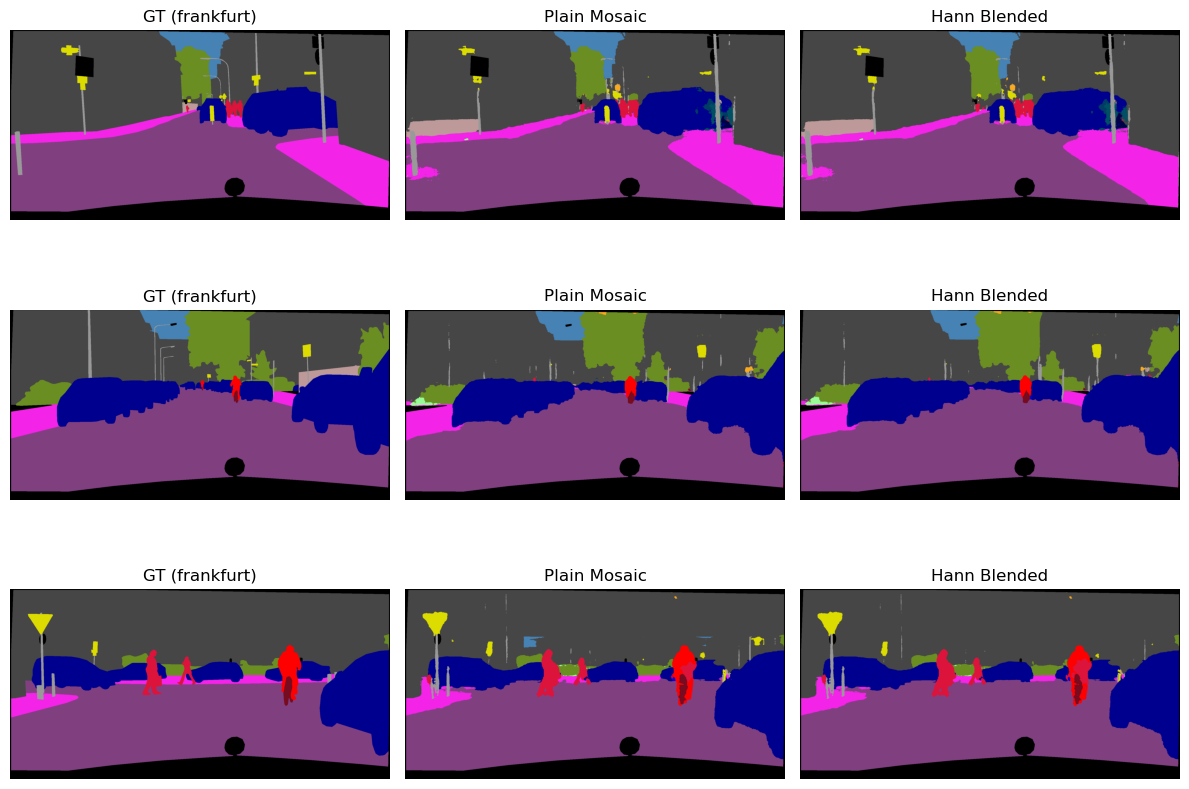

In [12]:
# ==============================================================
# Show 10 validation samples: GT vs Plain Mosaic vs Hann Blended
# ==============================================================

num_samples = 3
fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples*3))

for i in range(num_samples):
    img_path = val_imgs[i]
    msk_path = val_msks[i]
    city_name = os.path.basename(os.path.dirname(img_path))

    # --- Load full-res image and labelIds mask ---
    img_full = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    mask_full = cv2.imread(msk_path, cv2.IMREAD_UNCHANGED)
    gt = LUT[mask_full]

    # --- Half-res normalized tensor (same scale as training) ---
    img_05 = cv2.resize(img_full, None, fx=CFG.DOWNSAMPLE, fy=CFG.DOWNSAMPLE,
                         interpolation=cv2.INTER_LINEAR)
    img_t = val_tf_norm(image=img_05)["image"].unsqueeze(0).to(device)

    # --- Predict both mosaic and Hann blended ---
    logits_plain = predict_plain_logits(model, img_t, tile=CFG.TILE_SIZE, device=device)
    logits_hann  = predict_hann_logits(model, img_t, tile=CFG.TILE_SIZE,
                                       overlap=CFG.OVERLAP, device=device)

    # --- Upsample logits to full-res & argmax ---
    pred_plain = F.interpolate(logits_plain, size=gt.shape,
                               mode="bilinear", align_corners=False).argmax(1).squeeze(0).cpu().numpy()
    pred_hann  = F.interpolate(logits_hann, size=gt.shape,
                               mode="bilinear", align_corners=False).argmax(1).squeeze(0).cpu().numpy()

    # --- Mask voids (hood etc.) black for visualization ---
    void_mask = (LUT[mask_full] == 255)
    pred_plain[void_mask] = 255
    pred_hann[void_mask]  = 255
    gt[void_mask]         = 255

    # --- Colorize ---
    rgb_gt     = colorize_mask(gt)
    rgb_plain  = colorize_mask(pred_plain)
    rgb_hann   = colorize_mask(pred_hann)

    # --- Plot row ---
    axes[i,0].imshow(rgb_gt);    axes[i,0].set_title(f"GT ({city_name})"); axes[i,0].axis("off")
    axes[i,1].imshow(rgb_plain); axes[i,1].set_title("Plain Mosaic");      axes[i,1].axis("off")
    axes[i,2].imshow(rgb_hann);  axes[i,2].set_title("Hann Blended");      axes[i,2].axis("off")

plt.tight_layout()
plt.show()


## testing the ONNX model

In [13]:
import onnxruntime as ort


def run_onnx_inference_torch(model_path, input_tensor):
    """
    Runs inference on an ONNX model using ONNX Runtime with a PyTorch tensor as input.

    Args:
        model_path (str): Path to the ONNX model file.
        input_tensor (torch.Tensor): Input tensor in NCHW format (e.g., [B, C, H, W]).

    Returns:
        np.ndarray: Model output.
    """
    # Ensure tensor is on CPU and convert to NumPy
    input_np = input_tensor.detach().cpu().numpy().astype(np.float32)

    # Load ONNX model
    session = ort.InferenceSession(model_path, providers=["CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name

    # Run inference
    outputs = session.run(None, {input_name: input_np})
    return outputs[0]

In [14]:

# Example input tensor
x_test = torch.randn(4, 3, 384, 384, dtype=torch.float32)

# Run inference
result = run_onnx_inference_torch("./checkpoints/Akida_seg_tile.onnx", x_test)
print("Output shape:", result.shape)


Output shape: (4, 19, 384, 384)


In [15]:
@torch.no_grad()
def predict_plain_logits_tile(model, img, tile=384, overlap=64, device="cpu"):
    _,_,H,W = img.shape
    th = tw = tile
    ys = get_tile_starts(H, th, overlap)
    xs = get_tile_starts(W, tw, overlap)

    acc = torch.zeros((1, CFG.NUM_CLASSES, H, W), device=device)
    for y in ys:
        for x in xs:
            patch = img[:,:,y:y+th,x:x+tw]
            tmp = run_onnx_inference_torch("./checkpoints/Akida_seg_tile.onnx", patch)
            acc[:,:,y:y+th,x:x+tw] = torch.from_numpy(tmp)#.permute(0, 1, 3, 2) 

            # acc[:,:,y:y+th,x:x+tw] = model(patch)
    return acc

@torch.no_grad()
def predict_hann_logits_tile(model, img, tile=384, overlap=64, device="cpu"):
    _, _, H, W = img.shape
    th = tw = tile
    ys = get_tile_starts(H, th, overlap)
    xs = get_tile_starts(W, tw, overlap)

    acc = torch.zeros((1, CFG.NUM_CLASSES, H, W), device=device)
    wgt = torch.zeros((1, 1, H, W), device=device)
    win = make_hann_window(th, tw, device)

    for y in ys:
        for x in xs:
            patch = img[:, :, y:y+th, x:x+tw]
            # logits = model(patch)
            logits = run_onnx_inference_torch("./checkpoints/Akida_seg_tile.onnx", patch)
            logits = torch.from_numpy(logits)#.permute(0, 1, 3, 2) 
            

            acc[:, :, y:y+th, x:x+tw] += logits * win
            wgt[:, :, y:y+th, x:x+tw] += win

    return acc / wgt.clamp_min(1e-6)

In [16]:

# ---- main eval onnx ----
def eval_cityscapes_set(model, val_imgs, val_msks, use_hann=True, num_classes=19,
                        tile=CFG.TILE_SIZE, overlap=CFG.OVERLAP, downsample=CFG.DOWNSAMPLE, device=device,
                        max_images=None):
    conf = np.zeros((num_classes, num_classes), dtype=np.int64)
    gt_pixel_counts = np.zeros(num_classes, dtype=np.int64)

    N = len(val_imgs) if max_images is None else min(max_images, len(val_imgs))
    pbar = tqdm(range(N), desc="Evaluating")

    for i in pbar:
        img_path, msk_path = val_imgs[i], val_msks[i]

        img_full  = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask_full = cv2.imread(msk_path, cv2.IMREAD_UNCHANGED)
        gt = LUT[mask_full]  # [H,W]
        H, W = gt.shape

        # downsample to same scale as training
        img_05 = cv2.resize(img_full, None, fx=downsample, fy=downsample, interpolation=cv2.INTER_LINEAR)
        img_t  = val_tf_norm(image=img_05)["image"].unsqueeze(0).to(device)

        # run sliding window
        if use_hann:
            logits_05 = predict_hann_logits_tile(model, img_t, tile=tile, overlap=overlap, device='cpu')
        else:
            logits_05 = predict_plain_logits_tile(model, img_t, tile=tile, overlap=overlap, device='cpu')

        # upsample to full-res and take argmax
        pred = F.interpolate(logits_05, size=(H,W), mode="bilinear", align_corners=False)\
                .argmax(1).squeeze(0).cpu().numpy().astype(np.int64)

        # ignore void
        valid = gt != 255
        g = gt[valid].astype(np.int64)
        p = pred[valid].astype(np.int64)

        gt_pixel_counts += np.bincount(g, minlength=num_classes)
        k = num_classes * g + p
        conf += np.bincount(k, minlength=num_classes**2).reshape(num_classes, num_classes)

    inter = np.diag(conf)
    union = conf.sum(1) + conf.sum(0) - inter
    iou   = np.where(union > 0, inter / union, np.nan)
    miou  = np.nanmean(iou)

    total_gt = gt_pixel_counts.sum()
    gt_percent = (gt_pixel_counts / total_gt * 100.0) if total_gt > 0 else np.zeros_like(gt_pixel_counts, dtype=float)
    return iou, miou, gt_pixel_counts, gt_percent, conf

# ---- Run both ----
ious_mosaic, miou_mosaic, gt_counts, gt_pct, _ = eval_cityscapes_set(
    model, val_imgs, val_msks, use_hann=False, num_classes=CFG.NUM_CLASSES
)
ious_hann, miou_hann, _, _, _ = eval_cityscapes_set(
    model, val_imgs, val_msks, use_hann=True, num_classes=CFG.NUM_CLASSES
)

# ---- Pretty print ----
print("\nPer-class IoU (NaN = class absent across evaluated images):")
print(f"{'Class':<18} | {'IoU Mosaic':>10} | {'IoU Hann':>9} | {'GT %':>7}")
print("-"*56)
for n, im, ih, gp in zip(CLASS_NAMES, ious_mosaic, ious_hann, gt_pct):
    m = f"{im*100:8.2f}%" if np.isfinite(im) else "   NaN  "
    h = f"{ih*100:8.2f}%" if np.isfinite(ih) else "   NaN  "
    print(f"{n:<18} | {m} | {h} | {gp:6.2f}%")
print("-"*56)
print(f"{'mIoU':<18} | {miou_mosaic*100:8.2f}% | {miou_hann*100:8.2f}% |")


Evaluating: 100%|██████████| 500/500 [08:14<00:00,  1.01it/s]


Per-class IoU (NaN = class absent across evaluated images):
Class              | IoU Mosaic |  IoU Hann |    GT %
--------------------------------------------------------
road               |    96.57% |    96.63% |  37.65%
sidewalk           |    76.30% |    76.50% |   5.41%
building           |    87.58% |    88.39% |  21.92%
wall               |    36.85% |    40.76% |   0.73%
fence              |    38.18% |    40.98% |   0.82%
pole               |    50.81% |    52.62% |   1.48%
traffic light      |    45.97% |    48.08% |   0.20%
traffic sign       |    58.89% |    60.87% |   0.67%
vegetation         |    88.91% |    89.29% |  17.32%
terrain            |    46.90% |    47.35% |   0.83%
sky                |    91.81% |    92.22% |   3.35%
person             |    65.66% |    66.41% |   1.30%
rider              |    48.17% |    49.10% |   0.22%
car                |    89.89% |    90.95% |   6.51%
truck              |    47.51% |    55.76% |   0.30%
bus                |    56.47% | 

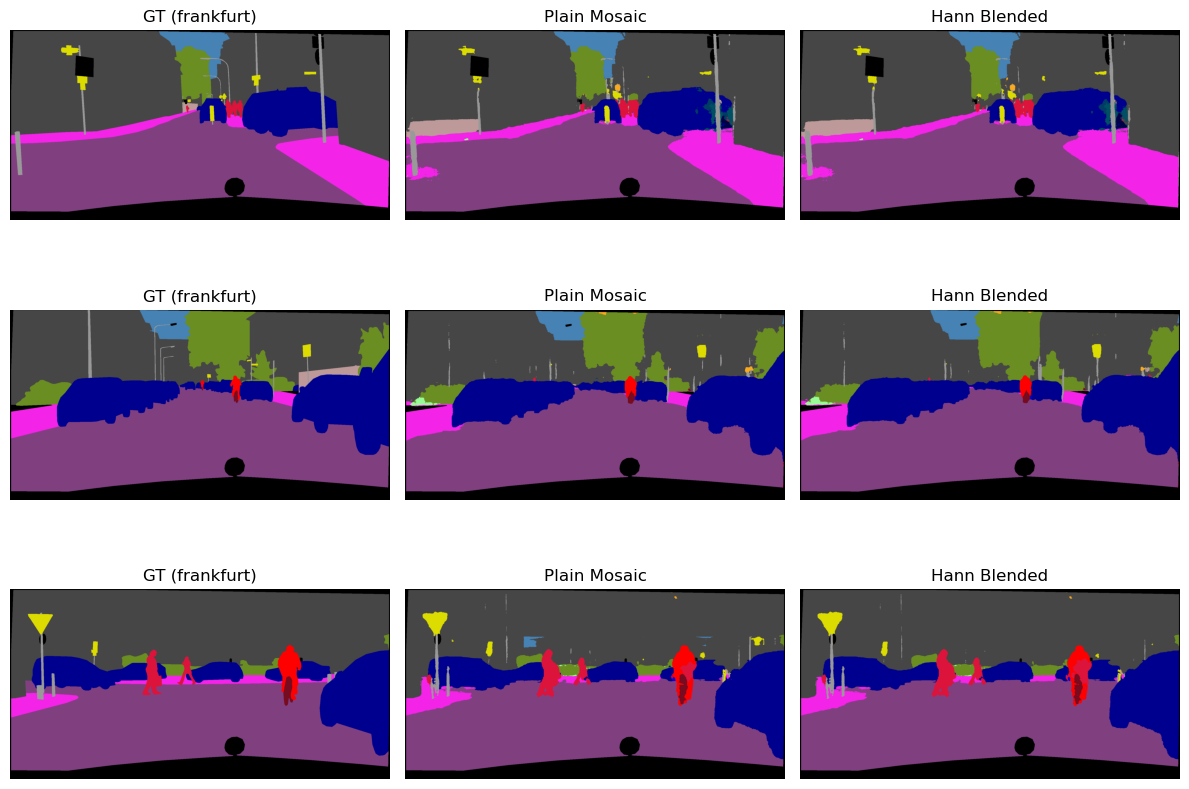

In [17]:
# ==============================================================
# Show 10 validation samples: GT vs Plain Mosaic vs Hann Blended
# ==============================================================

num_samples = 3
fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples*3))

for i in range(num_samples):
    img_path = val_imgs[i]
    msk_path = val_msks[i]
    city_name = os.path.basename(os.path.dirname(img_path))

    # --- Load full-res image and labelIds mask ---
    img_full = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    mask_full = cv2.imread(msk_path, cv2.IMREAD_UNCHANGED)
    gt = LUT[mask_full]

    # --- Half-res normalized tensor (same scale as training) ---
    img_05 = cv2.resize(img_full, None, fx=CFG.DOWNSAMPLE, fy=CFG.DOWNSAMPLE,
                         interpolation=cv2.INTER_LINEAR)
    img_t = val_tf_norm(image=img_05)["image"].unsqueeze(0).to(device)



    # run sliding window
    logits_hann = predict_hann_logits_tile(model, img_t, tile=CFG.TILE_SIZE, overlap=CFG.OVERLAP, device='cpu')
    logits_plain = predict_plain_logits_tile(model, img_t, tile=CFG.TILE_SIZE, overlap=CFG.OVERLAP, device='cpu')

    # # upsample to full-res and take argmax
    # pred = F.interpolate(logits_05, size=(H,W), mode="bilinear", align_corners=False)\
    #         .argmax(1).squeeze(0).cpu().numpy().astype(np.int64)
            
            



    # --- Predict both mosaic and Hann blended ---
    # logits_plain = predict_plain_logits(model, img_t, tile=CFG.TILE_SIZE, device=device)
    # logits_hann  = predict_hann_logits(model, img_t, tile=CFG.TILE_SIZE,
    #                                    overlap=CFG.OVERLAP, device=device)

    # --- Upsample logits to full-res & argmax ---
    pred_plain = F.interpolate(logits_plain, size=gt.shape,
                               mode="bilinear", align_corners=False).argmax(1).squeeze(0).cpu().numpy()
    pred_hann  = F.interpolate(logits_hann, size=gt.shape,
                               mode="bilinear", align_corners=False).argmax(1).squeeze(0).cpu().numpy()

    # --- Mask voids (hood etc.) black for visualization ---
    void_mask = (LUT[mask_full] == 255)
    pred_plain[void_mask] = 255
    pred_hann[void_mask]  = 255
    gt[void_mask]         = 255

    # --- Colorize ---
    rgb_gt     = colorize_mask(gt)
    rgb_plain  = colorize_mask(pred_plain)
    rgb_hann   = colorize_mask(pred_hann)

    # --- Plot row ---
    axes[i,0].imshow(rgb_gt);    axes[i,0].set_title(f"GT ({city_name})"); axes[i,0].axis("off")
    axes[i,1].imshow(rgb_plain); axes[i,1].set_title("Plain Mosaic");      axes[i,1].axis("off")
    axes[i,2].imshow(rgb_hann);  axes[i,2].set_title("Hann Blended");      axes[i,2].axis("off")

plt.tight_layout()
plt.show()


## Now with the Akida .h5 model

In [12]:
from akida import Model

# Load the original Keras model
# model = Model("./checkpoints/Akida_seg_tile.h5")
# model = Model("./checkpoints/Akida_seg_tile_ft_tiles_overlap.fpz")
model = Model("./checkpoints/Akida_seg_tile_dec15_more.fpz")


model.summary()


                  Model Summary                   
__________________________________________________
Input shape    Output shape    Sequences  Layers
[384, 384, 3]  [384, 384, 19]  1          83    
__________________________________________________

__________________________________________________________________________________________________________________________
Layer (type)                                                                            Output shape    Kernel shape    

================================= SW//encoder/conv_stem/conv/Conv-dequantizer (Software) =================================

/encoder/conv_stem/conv/Conv (InputConv2D)                                              [192, 192, 32]  (3, 3, 3, 32)   
__________________________________________________________________________________________________________________________
/encoder/act1/Relu_output_0_identity_conv (Conv2D)                                      [192, 192, 32]  (1, 1, 32, 32)  
______________

In [13]:
# first on a single image
# Example input (should match your preprocessing)
x = np.random.rand(1, 384, 384, 3).astype("uint8")

# Run on Akida model
preds = model.predict(x)
print(preds.shape)


(1, 384, 384, 19)


In [14]:
@torch.no_grad()
def predict_plain_logits_tile_akida(model, img, tile=384, overlap=64, device="cpu"):
    _,_,H,W = img.shape
    th = tw = tile
    ys = get_tile_starts(H, th, overlap)
    xs = get_tile_starts(W, tw, overlap)

    acc = torch.zeros((1, CFG.NUM_CLASSES, H, W), device=device)
    # print(acc.shape)

    for y in ys:
        for x in xs:
            patch = img[:,:,y:y+th,x:x+tw].permute(0, 2, 3, 1)
            # print(patch.shape)
            # tmp = run_onnx_inference_torch("./checkpoints/Akida_seg_tile.onnx", patch)
            tmp = model.predict(patch.numpy().astype("uint8"))
            # print(tmp.shape)
            

            acc[:,:,y:y+th,x:x+tw] = torch.from_numpy(tmp).permute(0, 3, 1, 2) 

            # acc[:,:,y:y+th,x:x+tw] = model(patch)
    return acc

@torch.no_grad()
def predict_hann_logits_tile_akida(model, img, tile=384, overlap=64, device="cpu"):
    _, _, H, W = img.shape
    th = tw = tile
    ys = get_tile_starts(H, th, overlap)
    xs = get_tile_starts(W, tw, overlap)

    acc = torch.zeros((1, CFG.NUM_CLASSES, H, W), device=device)
    wgt = torch.zeros((1, 1, H, W), device=device)
    win = make_hann_window(th, tw, device)

    for y in ys:
        for x in xs:
            patch = img[:, :, y:y+th, x:x+tw].permute(0, 2, 3, 1)
            # logits = model(patch)
            # logits = run_onnx_inference_torch("./checkpoints/Akida_seg_tile.onnx", patch)
            logits = model.predict(patch.numpy().astype("uint8"))
            logits = torch.from_numpy(logits).permute(0, 3, 1, 2) 
            

            acc[:, :, y:y+th, x:x+tw] += logits * win
            wgt[:, :, y:y+th, x:x+tw] += win

    return acc / wgt.clamp_min(1e-6)

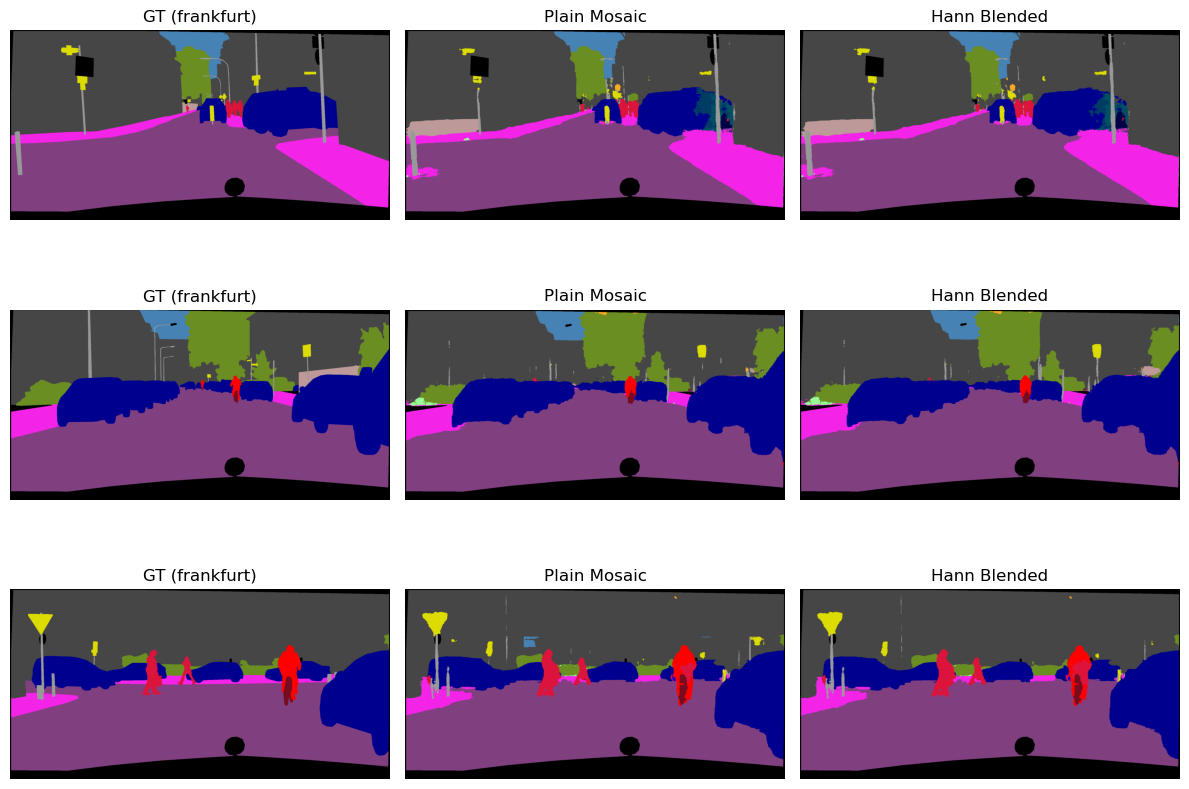

In [15]:
# ==============================================================
# Show 10 validation samples: GT vs Plain Mosaic vs Hann Blended
# ==============================================================

num_samples = 3
fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples*3))

for i in range(num_samples):
    img_path = val_imgs[i]
    msk_path = val_msks[i]
    city_name = os.path.basename(os.path.dirname(img_path))

    # --- Load full-res image and labelIds mask ---
    img_full = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    mask_full = cv2.imread(msk_path, cv2.IMREAD_UNCHANGED)
    gt = LUT[mask_full]

    # --- Half-res normalized tensor (same scale as training) ---
    # img_05 = cv2.resize(img_full, None, fx=CFG.DOWNSAMPLE, fy=CFG.DOWNSAMPLE,
    #                      interpolation=cv2.INTER_LINEAR)
    # img_t = val_tf_norm(image=img_05)["image"].unsqueeze(0)#.to(device)
    
    
    img_05 = cv2.resize(img_full, None, fx=CFG.DOWNSAMPLE, fy=CFG.DOWNSAMPLE,
                         interpolation=cv2.INTER_LINEAR)   

    # img_t = torch.from_numpy(cv2.resize(img_full, (384,384),
                        #  interpolation=cv2.INTER_LINEAR)).unsqueeze(0).permute(0, 3, 1, 2)
    
    img_t =  torch.from_numpy(img_05).unsqueeze(0).permute(0, 3, 1, 2)
    
    # print(img_t.shape)
    # --- Predict both mosaic and Hann blended ---
    # logits_plain = predict_plain_logits_tile_akida(model, img_t, tile=CFG.TILE_SIZE, device='cpu')
    logits_plain = predict_plain_logits_tile_akida(model, img_t, tile=CFG.TILE_SIZE, overlap=CFG.OVERLAP, device='cpu')

    logits_hann  = predict_hann_logits_tile_akida(model, img_t, tile=CFG.TILE_SIZE,
                                       overlap=CFG.OVERLAP, device='cpu')

    # --- Upsample logits to full-res & argmax ---
    pred_plain = F.interpolate(logits_plain, size=gt.shape,
                               mode="bilinear", align_corners=False).argmax(1).squeeze(0).cpu().numpy()
    pred_hann  = F.interpolate(logits_hann, size=gt.shape,
                               mode="bilinear", align_corners=False).argmax(1).squeeze(0).cpu().numpy()

    # --- Mask voids (hood etc.) black for visualization ---
    void_mask = (LUT[mask_full] == 255)
    pred_plain[void_mask] = 255
    pred_hann[void_mask]  = 255
    gt[void_mask]         = 255

    # --- Colorize ---
    rgb_gt     = colorize_mask(gt)
    rgb_plain  = colorize_mask(pred_plain)
    rgb_hann   = colorize_mask(pred_hann)

    # --- Plot row ---
    axes[i,0].imshow(rgb_gt);    axes[i,0].set_title(f"GT ({city_name})"); axes[i,0].axis("off")
    axes[i,1].imshow(rgb_plain); axes[i,1].set_title("Plain Mosaic");      axes[i,1].axis("off")
    axes[i,2].imshow(rgb_hann);  axes[i,2].set_title("Hann Blended");      axes[i,2].axis("off")

plt.tight_layout()
plt.show()


In [44]:
print(img_t.shape)
print(img_full.shape)

torch.Size([1, 3, 384, 384])
(1024, 2048, 3)


In [16]:

# ---- main eval onnx ----
def eval_cityscapes_set_akida(model, val_imgs, val_msks, use_hann=True, num_classes=19,
                        tile=CFG.TILE_SIZE, overlap=CFG.OVERLAP, downsample=CFG.DOWNSAMPLE, device=device,
                        max_images=None):
    conf = np.zeros((num_classes, num_classes), dtype=np.int64)
    gt_pixel_counts = np.zeros(num_classes, dtype=np.int64)

    N = len(val_imgs) if max_images is None else min(max_images, len(val_imgs))
    pbar = tqdm(range(N), desc="Evaluating")

    for i in pbar:
        img_path, msk_path = val_imgs[i], val_msks[i]

        img_full  = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask_full = cv2.imread(msk_path, cv2.IMREAD_UNCHANGED)
        gt = LUT[mask_full]  # [H,W]
        H, W = gt.shape
        
        
        # img_t = torch.from_numpy(cv2.resize(img_full, (384,384),
        #                     interpolation=cv2.INTER_LINEAR)).unsqueeze(0).permute(0, 3, 1, 2)
        
    
        img_05 = cv2.resize(img_full, None, fx=CFG.DOWNSAMPLE, fy=CFG.DOWNSAMPLE,
                        interpolation=cv2.INTER_LINEAR)   

        img_t =  torch.from_numpy(img_05).unsqueeze(0).permute(0, 3, 1, 2)
        
        # print(img_t.shape)
        # --- Predict both mosaic and Hann blended ---
        if use_hann:
            logits  = predict_hann_logits_tile_akida(model, img_t, tile=CFG.TILE_SIZE,
                                        overlap=CFG.OVERLAP, device='cpu')            
        else:
            logits = predict_plain_logits_tile_akida(model, img_t, tile=CFG.TILE_SIZE, overlap=CFG.OVERLAP, device='cpu')


        # --- Upsample logits to full-res & argmax ---
        pred = F.interpolate(logits, size=gt.shape,
                                mode="bilinear", align_corners=False).argmax(1).squeeze(0).cpu().numpy()
            
        # # downsample to same scale as training
        # img_05 = cv2.resize(img_full, None, fx=downsample, fy=downsample, interpolation=cv2.INTER_LINEAR)
        # img_t  = val_tf_norm(image=img_05)["image"].unsqueeze(0).to(device)

        # # run sliding window
        # if use_hann:
        #     logits_05 = predict_hann_logits_tile(model, img_t, tile=tile, overlap=overlap, device='cpu')
        # else:
        #     logits_05 = predict_plain_logits_tile(model, img_t, tile=tile, overlap=overlap, device='cpu')

        # # upsample to full-res and take argmax
        # pred = F.interpolate(logits_05, size=(H,W), mode="bilinear", align_corners=False)\
        #         .argmax(1).squeeze(0).cpu().numpy().astype(np.int64)

        # ignore void
        valid = gt != 255
        g = gt[valid].astype(np.int64)
        p = pred[valid].astype(np.int64)

        gt_pixel_counts += np.bincount(g, minlength=num_classes)
        k = num_classes * g + p
        conf += np.bincount(k, minlength=num_classes**2).reshape(num_classes, num_classes)

    inter = np.diag(conf)
    union = conf.sum(1) + conf.sum(0) - inter
    iou   = np.where(union > 0, inter / union, np.nan)
    miou  = np.nanmean(iou)

    total_gt = gt_pixel_counts.sum()
    gt_percent = (gt_pixel_counts / total_gt * 100.0) if total_gt > 0 else np.zeros_like(gt_pixel_counts, dtype=float)
    return iou, miou, gt_pixel_counts, gt_percent, conf

# ---- Run both ----
ious_mosaic, miou_mosaic, gt_counts, gt_pct, _ = eval_cityscapes_set_akida(
    model, val_imgs, val_msks, use_hann=False, num_classes=CFG.NUM_CLASSES
)
# ious_hann, miou_hann, _, _, _ = eval_cityscapes_set_akida(
#     model, val_imgs, val_msks, use_hann=True, num_classes=CFG.NUM_CLASSES
# )

# ---- Pretty print ----
print("\nPer-class IoU (NaN = class absent across evaluated images):")
print(f"{'Class':<18} | {'IoU Mosaic':>10} | {'GT %':>7}")
print("-"*56)
for n, im, gp in zip(CLASS_NAMES, ious_mosaic, gt_pct):
    m = f"{im*100:8.2f}%" if np.isfinite(im) else "   NaN  "
    print(f"{n:<18} | {m} | {gp:6.2f}%")
print("-"*56)
print(f"{'mIoU':<18} | {miou_mosaic*100:8.2f}% | ")


Evaluating: 100%|██████████| 500/500 [1:10:13<00:00,  8.43s/it]


Per-class IoU (NaN = class absent across evaluated images):
Class              | IoU Mosaic |    GT %
--------------------------------------------------------
road               |    96.65% |  37.65%
sidewalk           |    76.11% |   5.41%
building           |    87.20% |  21.92%
wall               |    35.80% |   0.73%
fence              |    37.09% |   0.82%
pole               |    50.66% |   1.48%
traffic light      |    45.46% |   0.20%
traffic sign       |    58.81% |   0.67%
vegetation         |    88.80% |  17.32%
terrain            |    47.82% |   0.83%
sky                |    91.51% |   3.35%
person             |    66.30% |   1.30%
rider              |    48.71% |   0.22%
car                |    89.76% |   6.51%
truck              |    46.44% |   0.30%
bus                |    55.51% |   0.39%
train              |    29.92% |   0.11%
motorcycle         |    34.04% |   0.08%
bicycle            |    65.30% |   0.71%
--------------------------------------------------------
mIoU